# Experimental FSPS Spectrum Fitting With `sedinfer`

This notebook is a first spectrum-fitting smoke test for the backend-agnostic spectral likelihood.

The experiment is deliberately controlled:

1. make one mock observed-frame galaxy spectrum with `FSPSBackend`;
2. keep the true redshift, dust, gas, and SFH fixed;
3. add realistic-ish Gaussian noise and mask common bad wavelength windows;
4. fit `log10_mass` and stellar metallicity `logzsol` with an `inftools` optimizer/Laplace approximation;
5. compare the recovered posterior region to the known truth.

The goal is not a production spectroscopic fit yet. It is to make sure the package interfaces, units, masks, and mass normalization behave correctly for spectra.


In [1]:
from __future__ import annotations

import importlib.util
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from sedinfer.backends.fsps import FSPSBackend
from sedinfer.data import SpectrumDataset
from sedinfer.likelihood import GaussianSpectralLikelihood
from sedinfer.parameters import ParameterSpace
from sedinfer.priors import UniformPrior
from sedinfer.units import MassNormalization

from inftools.core import Posterior
from inftools.laplace import run_laplace

plt.rcParams.update({"font.size": 12})


## Runtime Checks And Reproducibility

This notebook needs a real FSPS environment. It will fail early if `python-fsps` is not importable or if `SPS_HOME` is not set.


In [2]:
if importlib.util.find_spec("fsps") is None:
    raise ImportError("This notebook requires python-fsps. Install it in the active environment first.")

if not os.environ.get("SPS_HOME"):
    raise RuntimeError("SPS_HOME is not set. Point it at the FSPS/SPS grid directory before running.")

RNG_SEED = 240515
rng = np.random.default_rng(RNG_SEED)

OUTPUT_DIR = Path("outputs/experimental_fsps_spectrum_fitting")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("SPS_HOME:", os.environ["SPS_HOME"])
print("output directory:", OUTPUT_DIR)


SPS_HOME: /Users/gregoire/Work/FSPS
output directory: outputs/experimental_fsps_spectrum_fitting


## Scientific Setup

The spectrum is observed-frame `f_lambda` in `erg s^-1 cm^-2 Angstrom^-1`. FSPS returns a spectrum per solar mass because the backend is configured with `MassNormalization.PER_SOLAR_MASS`; the mock observation is made absolute by multiplying by `10**log10_mass_true`.

The wavelength grid is a simple optical window with a few masked regions that mimic sky/telluric contamination. The mask is part of `SpectrumDataset`, so the likelihood and the fit use exactly the same active pixels.


In [3]:
# Observed-frame wavelength grid for the synthetic spectrograph.
WAVELENGTH_OBS_A = np.arange(3800.0, 8500.0 + 1e-6, 5.0)

# Keep these windows out of the likelihood. They are intentionally approximate:
# [O I] sky line around 5577 A, atmospheric B band, and atmospheric A band.
MASKED_WINDOWS_A = [
    (5560.0, 5600.0),
    (6860.0, 6960.0),
    (7580.0, 7700.0),
]

active_mask = np.ones_like(WAVELENGTH_OBS_A, dtype=bool)
for lo, hi in MASKED_WINDOWS_A:
    active_mask &= ~((WAVELENGTH_OBS_A >= lo) & (WAVELENGTH_OBS_A <= hi))

print(f"wavelength pixels: {WAVELENGTH_OBS_A.size:,}")
print(f"active pixels:     {np.count_nonzero(active_mask):,}")
print(f"masked pixels:     {np.count_nonzero(~active_mask):,}")


wavelength pixels: 941
active pixels:     886
masked pixels:     55


In [4]:
# Fixed physical parameters for the mock galaxy. Time is in Gyr and SFR is in Msun/yr.
# Because the backend is PER_SOLAR_MASS, the absolute scale of this SFH is normalized away.
FIXED_FSPS_PARAMS = {
    "z": 0.35,
    "dust2": 0.25,
    "dust1": 0.0,
    "dust_index": -0.7,
    "gas_logz": -0.35,
    "gas_logu": -2.0,
    "tabular_time_gyr": np.array([0.05, 0.5, 2.0, 6.0]),
    "tabular_sfr_msun_per_yr": np.array([2.0, 3.0, 1.0, 0.25]),
}

TRUE_FREE_PARAMS = {
    "log10_mass": 10.25,
    "logzsol": -0.35,
}

FSPS_SP_KWARGS = {
    "zcontinuous": 1,
    "sfh": 3,
    "add_dust_emission": False,
    "add_neb_emission": True,
    "add_igm_absorption": True,
    "igm_factor": 1.0,
    "compute_vega_mags": False,
}

print("fixed redshift:", FIXED_FSPS_PARAMS["z"])
print("true log10_mass:", TRUE_FREE_PARAMS["log10_mass"])
print("true logzsol:", TRUE_FREE_PARAMS["logzsol"])


fixed redshift: 0.35
true log10_mass: 10.25
true logzsol: -0.35


## A Small Adapter For Fixed Nuisance Parameters

`ParameterSpace` contains scalar fitted parameters. The tabular SFH arrays and fixed nuisance parameters live in the backend adapter below. This keeps the likelihood focused on the actual fit parameters while still using the production `FSPSBackend.predict_spectrum` implementation.


In [5]:
class FixedNuisanceFSPSBackend(FSPSBackend):
    """FSPS backend with fixed SFH/redshift/dust parameters for this notebook."""

    def __init__(self, fixed_params, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.fixed_params = dict(fixed_params)

    def predict_spectrum(self, params, wavelengths=None, wavelength_range=None, resolution=None):
        merged = dict(self.fixed_params)
        merged.update(dict(params))
        return super().predict_spectrum(
            merged,
            wavelengths=wavelengths,
            wavelength_range=wavelength_range,
            resolution=resolution,
        )


backend = FixedNuisanceFSPSBackend(
    FIXED_FSPS_PARAMS,
    sp_kwargs=FSPS_SP_KWARGS,
    mass_normalization=MassNormalization.PER_SOLAR_MASS,
    default_z_key="z",
)

parameter_space = ParameterSpace(
    names=["log10_mass", "logzsol"],
    priors={
        "log10_mass": UniformPrior(9.5, 11.0),
        "logzsol": UniformPrior(-1.0, 0.2),
    },
)

print("fit parameter order:", parameter_space.names)
print("backend mass normalization:", backend.mass_normalization.name)


fit parameter order: ('log10_mass', 'logzsol')
backend mass normalization: PER_SOLAR_MASS


## Generate The Mock Spectrum

The mock observation is produced by the same backend used later for fitting. Noise is diagonal Gaussian in flux units with a fractional term plus a small absolute floor.


In [6]:
truth_model_per_msun = backend.predict_spectrum(
    {"logzsol": TRUE_FREE_PARAMS["logzsol"]},
    wavelengths=WAVELENGTH_OBS_A,
)
truth_flux = (10.0 ** TRUE_FREE_PARAMS["log10_mass"]) * truth_model_per_msun.flux

frac_sigma = 0.03
sigma_floor = 0.01 * np.nanmedian(np.abs(truth_flux[active_mask]))
sigma_flux = np.sqrt((frac_sigma * np.abs(truth_flux)) ** 2 + sigma_floor**2)
observed_flux = truth_flux + rng.normal(0.0, sigma_flux)

spectrum_data = SpectrumDataset(
    wavelength=WAVELENGTH_OBS_A,
    flux=observed_flux,
    sigma=sigma_flux,
    mask=active_mask,
    metadata={
        "truth": TRUE_FREE_PARAMS,
        "fixed_fsps_params": FIXED_FSPS_PARAMS,
        "flux_unit": "erg/s/cm^2/angstrom",
        "wavelength_unit": "angstrom",
    },
)

print("flux unit: erg/s/cm^2/angstrom")
print("median S/N on active pixels:", np.median(np.abs(truth_flux[active_mask]) / sigma_flux[active_mask]))
print("observed flux finite:", np.isfinite(observed_flux).all())


flux unit: erg/s/cm^2/angstrom
median S/N on active pixels: 31.622776597306768
observed flux finite: True


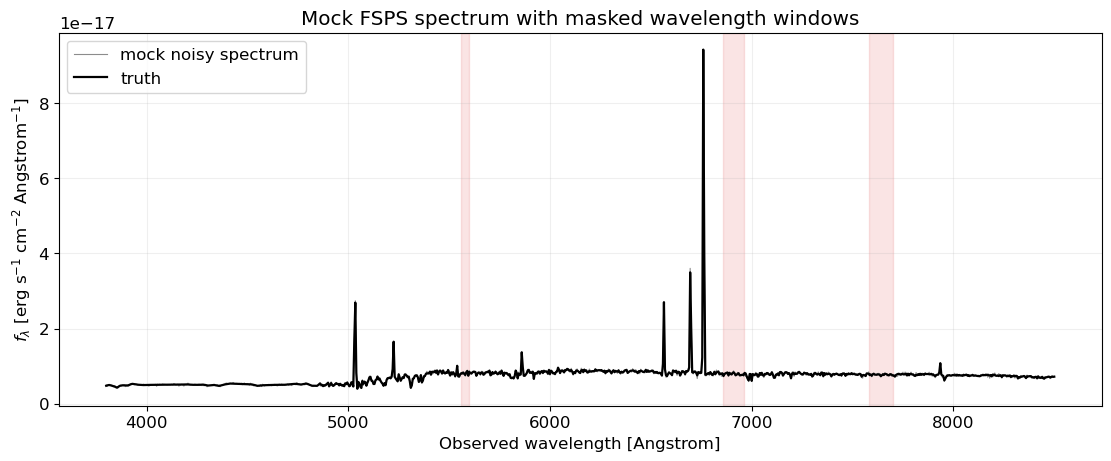

In [7]:
fig, ax = plt.subplots(figsize=(11, 4.5), constrained_layout=True)
ax.plot(WAVELENGTH_OBS_A, observed_flux, color="0.55", lw=0.8, label="mock noisy spectrum")
ax.plot(WAVELENGTH_OBS_A, truth_flux, color="black", lw=1.6, label="truth")
for lo, hi in MASKED_WINDOWS_A:
    ax.axvspan(lo, hi, color="tab:red", alpha=0.12)
ax.set_xlabel("Observed wavelength [Angstrom]")
ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
ax.set_title("Mock FSPS spectrum with masked wavelength windows")
ax.legend(loc="best")
ax.grid(alpha=0.2)
fig.savefig(OUTPUT_DIR / "mock_spectrum.png", dpi=180)
plt.show()


## Build The Spectral Likelihood

This object is the package interface we want to exercise. It uses the active wavelength pixels from `SpectrumDataset`, asks the backend for a spectrum on those wavelengths, applies the explicit mass normalization rule, and evaluates a diagonal Gaussian likelihood plus the prior.


In [8]:
likelihood = GaussianSpectralLikelihood(
    backend=backend,
    dataset=spectrum_data,
    parameter_space=parameter_space,
)

true_theta = parameter_space.from_dict(TRUE_FREE_PARAMS)
print("theta at truth:", true_theta)
print("log posterior at truth:", likelihood.log_prob(true_theta))


theta at truth: [10.25 -0.35]
log posterior at truth: 36783.414239665515


## Fit With `inftools`: Pilot Search + Multistart Laplace

Now we hand the sedinfer spectral likelihood to `inftools`. The `Posterior` wrapper is the common interface used by the samplers/optimizers.

A single local optimizer can lock onto a secondary metallicity solution, so the notebook does two lightweight but realistic things:

1. evaluate a small random pilot sample from the prior;
2. run `inftools.laplace.run_laplace` from the best pilot points;
3. keep the highest-posterior MAP and use its local Hessian as the covariance.

This is still not a production global sampler, but it is a serious first fitting workflow and scales much better than a dense grid.


In [9]:
posterior = Posterior(
    log_prob_fn=likelihood.log_prob,
    dim=2,
    theta_names=parameter_space.names,
    extra={
        "dataset": spectrum_data,
        "backend": backend,
        "note": "FSPS mock spectrum; fitting log10_mass and logzsol only.",
    },
)

parameter_bounds = [(9.5, 11.0), (-1.0, 0.2)]

N_PILOT = 80
N_LAPLACE_STARTS = 4
pilot_theta = parameter_space.sample_prior(N_PILOT, rng=rng)
pilot_logp = np.array([posterior.log_prob_fn(theta) for theta in pilot_theta], dtype=float)
finite_pilot = np.isfinite(pilot_logp)
if not np.any(finite_pilot):
    raise RuntimeError("Every pilot point has non-finite log posterior.")

start_order = np.argsort(np.where(finite_pilot, pilot_logp, -np.inf))[::-1]
start_thetas = pilot_theta[start_order[:N_LAPLACE_STARTS]]

print("Best pilot starts:")
for rank, idx in enumerate(start_order[:N_LAPLACE_STARTS], start=1):
    print(f"  {rank}: theta={pilot_theta[idx]}, logp={pilot_logp[idx]:.3f}")

laplace_attempts = []
for rank, start_theta in enumerate(start_thetas, start=1):
    result = run_laplace(
        posterior,
        x0=start_theta,
        bounds=parameter_bounds,
        method="Powell",
    )
    map_theta_i = np.asarray(result.map_estimate, dtype=float)
    logp_i = float(result.logp[0])
    laplace_attempts.append(result)
    print(
        f"Laplace start {rank}: start={start_theta}, MAP={map_theta_i}, "
        f"logp={logp_i:.3f}, success={bool(result.meta['opt_result'].success)}"
    )

best_attempt_index = int(np.argmax([float(result.logp[0]) for result in laplace_attempts]))
laplace_result = laplace_attempts[best_attempt_index]
map_theta = np.asarray(laplace_result.map_estimate, dtype=float)
best_log10_mass = float(map_theta[parameter_space.names.index("log10_mass")])
best_logzsol = float(map_theta[parameter_space.names.index("logzsol")])

print("Selected Laplace attempt:", best_attempt_index + 1)
print("MAP theta:", map_theta)
print("MAP log posterior:", float(laplace_result.logp[0]))
print("optimizer success:", bool(laplace_result.meta["opt_result"].success))
print("optimizer message:", laplace_result.meta["opt_result"].message)
print("covariance matrix:")
print(laplace_result.cov)
print("truth:", parameter_space.from_dict(TRUE_FREE_PARAMS))
print("log posterior at truth:", likelihood.log_prob(parameter_space.from_dict(TRUE_FREE_PARAMS)))


Best pilot starts:
  1: theta=[10.26739657 -0.34740172], logp=36064.471
  2: theta=[10.30720522 -0.18577773], logp=35614.438
  3: theta=[10.21185606 -0.41630404], logp=35536.204
  4: theta=[10.26672006 -0.38571612], logp=35321.062


Laplace start 1: start=[10.26739657 -0.34740172], MAP=[10.24985633 -0.34798017], logp=36784.025, success=True


Laplace start 2: start=[10.30720522 -0.18577773], MAP=[10.28516069 -0.18671071], logp=36755.708, success=True


Laplace start 3: start=[10.21185606 -0.41630404], MAP=[10.2360505  -0.41476429], logp=36781.211, success=True


Laplace start 4: start=[10.26672006 -0.38571612], MAP=[10.2422093  -0.38511923], logp=36784.074, success=True
Selected Laplace attempt: 4
MAP theta: [10.2422093  -0.38511923]
MAP log posterior: 36784.074368071015
optimizer success: True
optimizer message: Optimization terminated successfully.
covariance matrix:
[[1.58100976e-05 7.63409273e-05]
 [7.63409273e-05 3.73810063e-04]]
truth: [10.25 -0.35]
log posterior at truth: 36783.414239665515


In [10]:
def regularize_covariance(cov, min_eigenvalue=1e-10):
    cov = np.asarray(cov, dtype=float)
    cov = 0.5 * (cov + cov.T)
    eigval, eigvec = np.linalg.eigh(cov)
    eigval = np.maximum(eigval, min_eigenvalue)
    return (eigvec * eigval) @ eigvec.T


def keep_prior_bounds(samples):
    samples = np.asarray(samples, dtype=float)
    keep = np.ones(samples.shape[0], dtype=bool)
    for i, theta in enumerate(samples):
        keep[i] = np.isfinite(parameter_space.log_prior(theta))
    return samples[keep]


N_LAPLACE_SAMPLES = 20_000
laplace_cov = regularize_covariance(laplace_result.cov)
laplace_samples = rng.multivariate_normal(mean=map_theta, cov=laplace_cov, size=N_LAPLACE_SAMPLES)
laplace_samples = keep_prior_bounds(laplace_samples)

log10_mass_samples = laplace_samples[:, parameter_space.names.index("log10_mass")]
logzsol_samples = laplace_samples[:, parameter_space.names.index("logzsol")]

logm_q16, logm_q50, logm_q84 = np.quantile(log10_mass_samples, [0.16, 0.5, 0.84])
logz_q16, logz_q50, logz_q84 = np.quantile(logzsol_samples, [0.16, 0.5, 0.84])

print(f"Laplace samples kept inside prior: {laplace_samples.shape[0]:,}/{N_LAPLACE_SAMPLES:,}")
print("Recovered metallicity logzsol:")
print(f"  truth:  {TRUE_FREE_PARAMS['logzsol']:.3f}")
print(f"  MAP:    {best_logzsol:.3f}")
print(f"  median: {logz_q50:.3f}  (-{logz_q50 - logz_q16:.3f}, +{logz_q84 - logz_q50:.3f})")
print("Recovered log10_mass:")
print(f"  truth:  {TRUE_FREE_PARAMS['log10_mass']:.3f}")
print(f"  MAP:    {best_log10_mass:.3f}")
print(f"  median: {logm_q50:.3f}  (-{logm_q50 - logm_q16:.3f}, +{logm_q84 - logm_q50:.3f})")


Laplace samples kept inside prior: 20,000/20,000
Recovered metallicity logzsol:
  truth:  -0.350
  MAP:    -0.385
  median: -0.385  (-0.019, +0.019)
Recovered log10_mass:
  truth:  10.250
  MAP:    10.242
  median: 10.242  (-0.004, +0.004)


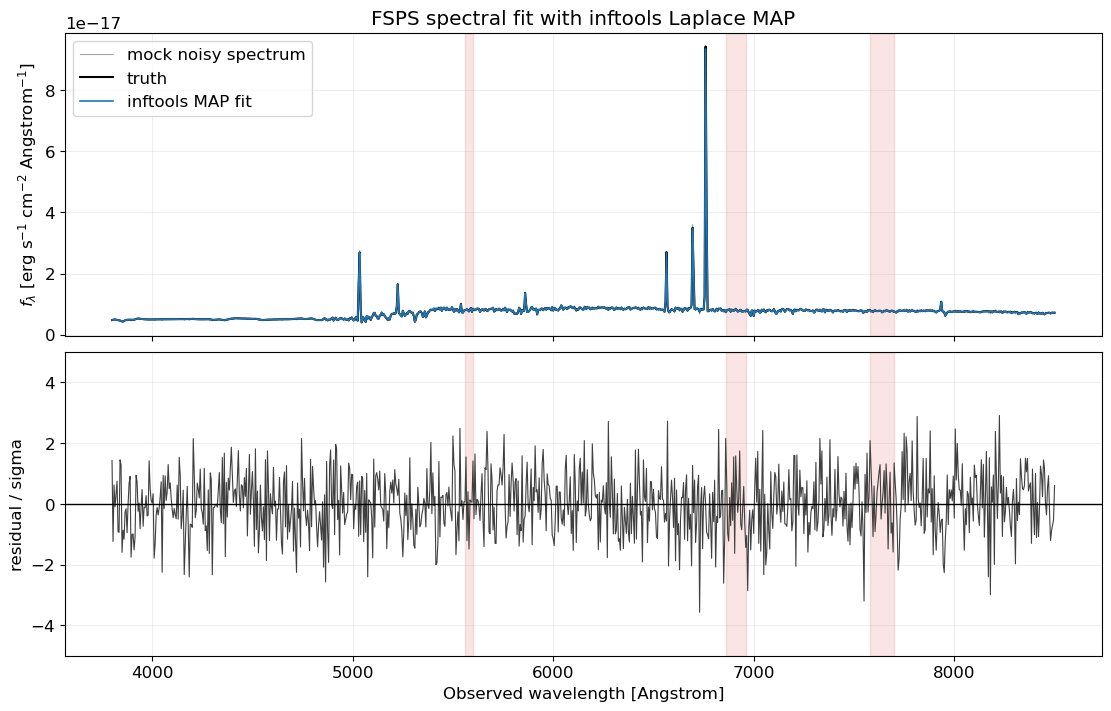

In [11]:
best_model_per_msun = backend.predict_spectrum({"logzsol": best_logzsol}, wavelengths=WAVELENGTH_OBS_A).flux
best_flux = (10.0 ** best_log10_mass) * best_model_per_msun

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True, constrained_layout=True)
ax, rax = axes
ax.plot(WAVELENGTH_OBS_A, observed_flux, color="0.65", lw=0.8, label="mock noisy spectrum")
ax.plot(WAVELENGTH_OBS_A, truth_flux, color="black", lw=1.5, label="truth")
ax.plot(WAVELENGTH_OBS_A, best_flux, color="tab:blue", lw=1.2, label="inftools MAP fit")
for lo, hi in MASKED_WINDOWS_A:
    ax.axvspan(lo, hi, color="tab:red", alpha=0.12)
    rax.axvspan(lo, hi, color="tab:red", alpha=0.12)

rax.plot(WAVELENGTH_OBS_A, (observed_flux - best_flux) / sigma_flux, color="0.25", lw=0.8)
rax.axhline(0.0, color="black", lw=1.0)
rax.set_ylim(-5.0, 5.0)

ax.set_ylabel(r"$f_\lambda$ [erg s$^{-1}$ cm$^{-2}$ Angstrom$^{-1}$]")
rax.set_ylabel("residual / sigma")
rax.set_xlabel("Observed wavelength [Angstrom]")
ax.set_title("FSPS spectral fit with inftools Laplace MAP")
ax.legend(loc="best")
for axis in axes:
    axis.grid(alpha=0.2)
fig.savefig(OUTPUT_DIR / "best_fit_spectrum.png", dpi=180)
plt.show()


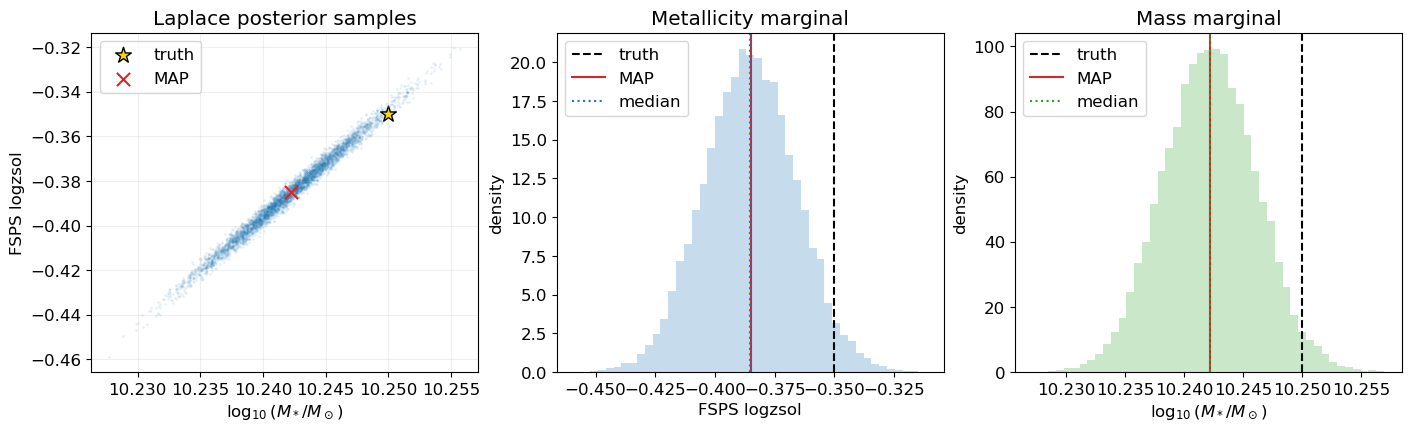

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)

ax = axes[0]
plot_samples = laplace_samples[:: max(1, laplace_samples.shape[0] // 5000)]
ax.scatter(
    plot_samples[:, parameter_space.names.index("log10_mass")],
    plot_samples[:, parameter_space.names.index("logzsol")],
    s=3,
    alpha=0.12,
    linewidths=0,
    rasterized=True,
)
ax.scatter(TRUE_FREE_PARAMS["log10_mass"], TRUE_FREE_PARAMS["logzsol"], marker="*", s=140, color="gold", edgecolor="black", label="truth")
ax.scatter(best_log10_mass, best_logzsol, marker="x", s=90, color="tab:red", label="MAP")
ax.set_xlabel(r"$\log_{10}(M_*/M_\odot)$")
ax.set_ylabel("FSPS logzsol")
ax.set_title("Laplace posterior samples")
ax.legend(loc="best")
ax.grid(alpha=0.2)

ax = axes[1]
ax.hist(logzsol_samples, bins=45, density=True, histtype="stepfilled", alpha=0.25, color="tab:blue")
ax.axvline(TRUE_FREE_PARAMS["logzsol"], color="black", ls="--", label="truth")
ax.axvline(best_logzsol, color="tab:red", ls="-", label="MAP")
ax.axvline(logz_q50, color="tab:blue", ls=":", label="median")
ax.set_xlabel("FSPS logzsol")
ax.set_ylabel("density")
ax.set_title("Metallicity marginal")
ax.legend(loc="best")

ax = axes[2]
ax.hist(log10_mass_samples, bins=45, density=True, histtype="stepfilled", alpha=0.25, color="tab:green")
ax.axvline(TRUE_FREE_PARAMS["log10_mass"], color="black", ls="--", label="truth")
ax.axvline(best_log10_mass, color="tab:red", ls="-", label="MAP")
ax.axvline(logm_q50, color="tab:green", ls=":", label="median")
ax.set_xlabel(r"$\log_{10}(M_*/M_\odot)$")
ax.set_ylabel("density")
ax.set_title("Mass marginal")
ax.legend(loc="best")

fig.savefig(OUTPUT_DIR / "laplace_posterior.png", dpi=180)
plt.show()


## Save Numerical Outputs

The saved file contains the mock data, mask, MAP estimate, Laplace covariance, and posterior samples. That is enough to remake the plots without rerunning FSPS.


In [13]:
np.savez_compressed(
    OUTPUT_DIR / "fsps_spectrum_fit_result.npz",
    wavelength_obs_a=WAVELENGTH_OBS_A,
    active_mask=active_mask,
    observed_flux=observed_flux,
    truth_flux=truth_flux,
    sigma_flux=sigma_flux,
    map_theta=map_theta,
    laplace_cov=laplace_cov,
    laplace_samples=laplace_samples.astype(np.float32),
    best_logzsol=np.array(best_logzsol),
    best_log10_mass=np.array(best_log10_mass),
    logzsol_quantiles=np.array([logz_q16, logz_q50, logz_q84]),
    log10_mass_quantiles=np.array([logm_q16, logm_q50, logm_q84]),
    true_logzsol=np.array(TRUE_FREE_PARAMS["logzsol"]),
    true_log10_mass=np.array(TRUE_FREE_PARAMS["log10_mass"]),
)

print("saved:", OUTPUT_DIR / "fsps_spectrum_fit_result.npz")
print("saved:", OUTPUT_DIR / "mock_spectrum.png")
print("saved:", OUTPUT_DIR / "best_fit_spectrum.png")
print("saved:", OUTPUT_DIR / "laplace_posterior.png")


saved: outputs/experimental_fsps_spectrum_fitting/fsps_spectrum_fit_result.npz
saved: outputs/experimental_fsps_spectrum_fitting/mock_spectrum.png
saved: outputs/experimental_fsps_spectrum_fitting/best_fit_spectrum.png
saved: outputs/experimental_fsps_spectrum_fitting/laplace_posterior.png
